# Predictive Interval Calibration

Check whether Bayesian ±zσ intervals hit their nominal coverage on a hold-out set.


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from house_price_predictor import BayesianLinearRegression, build_feature_frame, load_housing_data, train_val_split
from house_price_predictor.calibration import calibration_curve, calibration_report, pit_values

train, _ = load_housing_data()
eng, _ = build_feature_frame(train, log_target=True)
X_tr, X_va, y_tr, y_va = train_val_split(eng.X, eng.y, random_state=42)
model = BayesianLinearRegression(0.1).fit(X_tr, y_tr)
mean, std = model.predict(X_va, return_std=True)
print(calibration_report(y_va, mean, std))


{'coverage_50': 0.6254295532646048, 'coverage_90': 0.9278350515463918, 'coverage_95': 0.9484536082474226, 'pit_mean': 0.5324861969352563, 'pit_std': 0.2581221168953782, 'mean_interval_width_95': 0.5118252142338922}


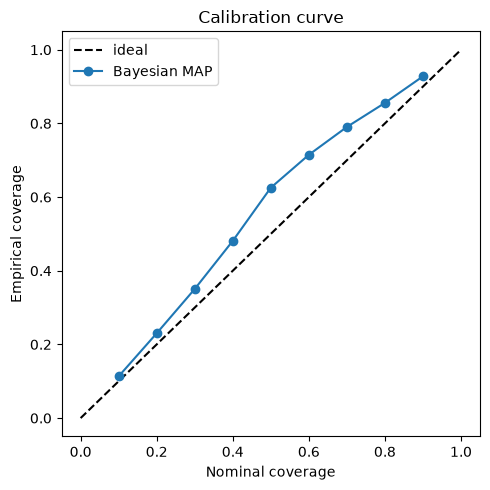

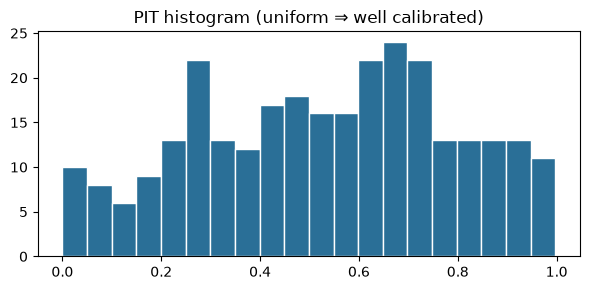

In [2]:
nominal, empirical = calibration_curve(y_va, mean, std)
plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1],"k--",label="ideal")
plt.plot(nominal, empirical, marker="o", label="Bayesian MAP")
plt.xlabel("Nominal coverage"); plt.ylabel("Empirical coverage")
plt.title("Calibration curve"); plt.legend(); plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "calibration_curve.png", dpi=120)
plt.show()

pit = pit_values(y_va, mean, std)
plt.figure(figsize=(6,3))
plt.hist(pit, bins=20, color="#2a6f97", edgecolor="white")
plt.title("PIT histogram (uniform ⇒ well calibrated)")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "calibration_pit.png", dpi=120)
plt.show()
